# Assignment 4 - Simple Neural Networks (**PyTorch Version**)

Build a fraud classifier from transaction data.


## What stays the same from the original assignment

- **Task:** predict fraud from transaction data.
- **Deliverables:** one training notebook and one prediction notebook.
- **Grading:**
  - Code produces predictions — **40**
  - Accuracy — **30**
  - Explanation — **20**
  - Balance / variable transformations — **10**








In [1]:
# Colab setup - run this first
import torch
print(torch.__version__)  # torch is already installed on Colab

2.10.0+cpu


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

import joblib
from pathlib import Path

# Device setup in the same spirit as the reference notebook
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


## Load Data

Expected training file: `fraudTrain.csv`


In [10]:
from google.colab import files
uploaded = files.upload()

Saving fraudTrain.csv.zip to fraudTrain.csv (1).zip


In [13]:
df = pd.read_csv("fraudTrain.csv (1).zip")
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
df.head()

(1296675, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [14]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
trans_date_trans_time,1296675,1274791,2019-04-22 16:02:01,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc_num,1296675.0,NaN,NaN,NaN,417192042079726656.0,1308806447000789248.0,60416207185.0,180042946491150.0,3521417320836166.0,4642255475285942.0,4992346398065154048.0
merchant,1296675,693,fraud_Kilback LLC,4403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1296675,14,gas_transport,131659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amt,1296675.0,NaN,NaN,NaN,70.351035,160.316039,1.0,9.65,47.52,83.14,28948.9
first,1296675,352,Christopher,26669,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,1296675,481,Smith,28794,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1296675,2,F,709863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street,1296675,983,864 Reynolds Plains,3123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1296675,894,Birmingham,5617,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Deal with Lat/Lon

A plain latitude/longitude pair is not usually ideal for a tabular neural network.
A more useful transformation is to create a **distance-like feature** between the customer and merchant.

**TODO:** create at least one useful location feature.
Suggested idea: distance between `(lat, long)` and `(merch_lat, merch_long)`.


In [15]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

df["distance_km"] = haversine_km(df["lat"], df["long"], df["merch_lat"], df["merch_long"])
print(df["distance_km"].describe())

count    1.296675e+06
mean     7.611465e+01
std      2.911693e+01
min      2.225452e-02
25%      5.533491e+01
50%      7.823175e+01
75%      9.850327e+01
max      1.521172e+02
Name: distance_km, dtype: float64


### Deal with Time

The original prompt suggests that time and DOB are not especially useful in raw form, but can become useful after transformation.

**TODO:** create time-based features such as:
- hour of day
- day of week
- month
- customer age
- cyclical encoding of hour


In [16]:
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["dob"] = pd.to_datetime(df["dob"])

df["hour"]         = df["trans_date_trans_time"].dt.hour
df["day_of_week"]  = df["trans_date_trans_time"].dt.dayofweek
df["month"]        = df["trans_date_trans_time"].dt.month
df["customer_age"] = ((df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25).astype(float)

# Cyclic hour encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Cyclic day-of-week encoding
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

print(df[["hour_sin","hour_cos","dow_sin","dow_cos","customer_age"]].describe())

           hour_sin      hour_cos       dow_sin       dow_cos  customer_age
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06
mean  -1.366887e-01 -1.406000e-02 -1.086901e-01  1.285135e-01  4.599640e+01
std    6.932213e-01  7.075051e-01  6.846294e-01  7.091926e-01  1.739402e+01
min   -1.000000e+00 -1.000000e+00 -9.749279e-01 -9.009689e-01  1.392197e+01
25%   -8.660254e-01 -7.071068e-01 -7.818315e-01 -2.225209e-01  3.259959e+01
50%   -2.588190e-01 -1.836970e-16  0.000000e+00  6.234898e-01  4.396988e+01
75%    5.000000e-01  7.071068e-01  4.338837e-01  6.234898e-01  5.707050e+01
max    1.000000e+00  1.000000e+00  9.749279e-01  1.000000e+00  9.563860e+01


### Check Target Balance

This dataset is imbalanced, so you should inspect the fraud rate before training.


is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud rate: 0.58%


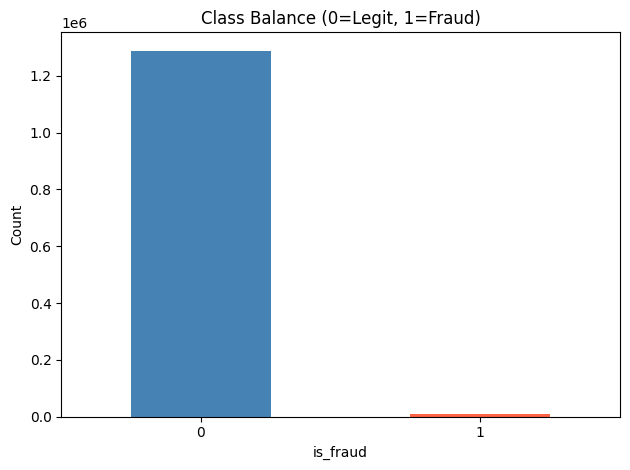

In [17]:
balance = df["is_fraud"].value_counts()
print(balance)
print(f"\nFraud rate: {balance[1] / balance.sum() * 100:.2f}%")

balance.plot(kind="bar", color=["steelblue","tomato"], rot=0)
plt.title("Class Balance (0=Legit, 1=Fraud)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Prepare Data

Recommended workflow:
1. Choose features.
2. Separate numeric and categorical columns.
3. One-hot encode categorical variables.
4. Standardize numeric variables.
5. Combine everything into a single feature matrix.

You should also decide which columns to drop because they are IDs, raw timestamps, or leakage-prone text fields.


In [18]:
TARGET = "is_fraud"

engineered_numeric = [
    "amt", "city_pop", "distance_km", "customer_age",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month"
]

categorical_cols = ["category", "gender"]

# One-hot encode categoricals
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
cat_encoded = encoder.fit_transform(df[categorical_cols])
cat_feature_names = encoder.get_feature_names_out(categorical_cols).tolist()

# Numeric matrix
num_matrix = df[engineered_numeric].values

# Combined feature matrix
X = np.hstack([num_matrix, cat_encoded])
y = df[TARGET].values

feature_cols = engineered_numeric + cat_feature_names

print(f"Feature matrix shape : {X.shape}")
print(f"Fraud rate           : {y.mean()*100:.2f}%")

Feature matrix shape : (1296675, 25)
Fraud rate           : 0.58%


### Split Data

Use a stratified split so the fraud rate stays similar in train/validation/test.


In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {X_train.shape}  fraud={y_train.mean()*100:.2f}%")
print(f"Valid : {X_valid.shape}  fraud={y_valid.mean()*100:.2f}%")
print(f"Test  : {X_test.shape}   fraud={y_test.mean()*100:.2f}%")

Train : (907672, 25)  fraud=0.58%
Valid : (194501, 25)  fraud=0.58%
Test  : (194502, 25)   fraud=0.58%


### Convert to Tensors and DataLoaders

Follow the reference notebook style:
- convert arrays to tensors
- wrap them in `TensorDataset`
- use `DataLoader`
- handle imbalance with either:
  - `WeightedRandomSampler`, or
  - `pos_weight` in `BCEWithLogitsLoss`


In [20]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s  = scaler.transform(X_test)

In [21]:
def to_tensor(X, y):
    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y.reshape(-1, 1), dtype=torch.float32)
    )

X_train_t, y_train_t = to_tensor(X_train_s, y_train)
X_valid_t, y_valid_t = to_tensor(X_valid_s, y_valid)
X_test_t,  y_test_t  = to_tensor(X_test_s,  y_test)

# WeightedRandomSampler to handle imbalance
class_counts = np.bincount(y_train)
weights = 1.0 / class_counts[y_train]
sampler = WeightedRandomSampler(
    weights=torch.tensor(weights, dtype=torch.float32),
    num_samples=len(weights),
    replacement=True
)

train_ds = TensorDataset(X_train_t, y_train_t)
valid_ds = TensorDataset(X_valid_t, y_valid_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=1024, sampler=sampler)
valid_loader = DataLoader(valid_ds, batch_size=2048, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=2048, shuffle=False)

print("DataLoaders ready.")

DataLoaders ready.


### Model

Build a small multilayer perceptron (MLP) for binary classification.

Suggested starting point:
- Linear → ReLU → Dropout
- Linear → ReLU → Dropout
- Linear → 1 output logit


In [22]:
class FraudMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)   # raw logit — BCEWithLogitsLoss handles sigmoid
        )

    def forward(self, x):
        return self.net(x)

model = FraudMLP(input_dim=X_train_s.shape[1]).to(device)
print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters()):,}")

FraudMLP(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 14,081


### Train the Model

Use:
- `BCEWithLogitsLoss`
- `Adam`
- an epoch loop with training and validation loss

You should move both the model and each batch to `device`.


In [23]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

EPOCHS = 20
best_auc   = 0.0
best_state = None

train_losses, valid_losses, valid_aucs = [], [], []

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(Xb)
    train_loss = running_loss / len(train_loader.dataset)

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    val_loss   = 0.0
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for Xb, yb in valid_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits = model(Xb)
            val_loss += criterion(logits, yb).item() * len(Xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(yb.cpu().numpy())

    val_loss  /= len(valid_loader.dataset)
    all_probs  = np.vstack(all_probs).flatten()
    all_labels = np.vstack(all_labels).flatten()
    val_auc    = roc_auc_score(all_labels, all_probs)

    train_losses.append(train_loss)
    valid_losses.append(val_loss)
    valid_aucs.append(val_auc)

    scheduler.step(val_auc)

    if val_auc > best_auc:
        best_auc   = val_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_AUC={val_auc:.4f}")

# Restore best weights
model.load_state_dict(best_state)
print(f"\nBest validation AUC: {best_auc:.4f}")

Epoch 01 | train_loss=0.1827 | val_loss=0.1020 | val_AUC=0.9949
Epoch 02 | train_loss=0.1015 | val_loss=0.0870 | val_AUC=0.9964
Epoch 03 | train_loss=0.0886 | val_loss=0.0807 | val_AUC=0.9968
Epoch 04 | train_loss=0.0844 | val_loss=0.0722 | val_AUC=0.9967
Epoch 05 | train_loss=0.0793 | val_loss=0.0747 | val_AUC=0.9969
Epoch 06 | train_loss=0.0767 | val_loss=0.0655 | val_AUC=0.9969
Epoch 07 | train_loss=0.0741 | val_loss=0.0703 | val_AUC=0.9968
Epoch 08 | train_loss=0.0726 | val_loss=0.0661 | val_AUC=0.9967
Epoch 09 | train_loss=0.0707 | val_loss=0.0694 | val_AUC=0.9967
Epoch 10 | train_loss=0.0661 | val_loss=0.0564 | val_AUC=0.9971
Epoch 11 | train_loss=0.0632 | val_loss=0.0614 | val_AUC=0.9970
Epoch 12 | train_loss=0.0645 | val_loss=0.0561 | val_AUC=0.9971
Epoch 13 | train_loss=0.0634 | val_loss=0.0663 | val_AUC=0.9969
Epoch 14 | train_loss=0.0601 | val_loss=0.0588 | val_AUC=0.9972
Epoch 15 | train_loss=0.0595 | val_loss=0.0568 | val_AUC=0.9969
Epoch 16 | train_loss=0.0601 | val_loss=

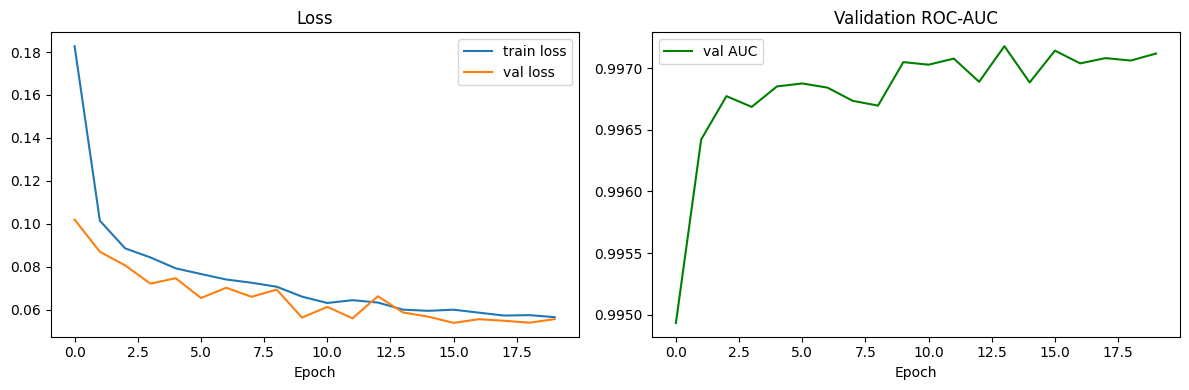

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train loss")
axes[0].plot(valid_losses, label="val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(valid_aucs, label="val AUC", color="green")
axes[1].set_title("Validation ROC-AUC")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

### Evaluate

At minimum, produce:
- confusion matrix
- classification report
- ROC-AUC if possible

You may also tune the classification threshold rather than always using 0.50.


ROC-AUC : 0.9969

              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99    193376
       Fraud       0.18      0.97      0.30      1126

    accuracy                           0.97    194502
   macro avg       0.59      0.97      0.64    194502
weighted avg       1.00      0.97      0.98    194502



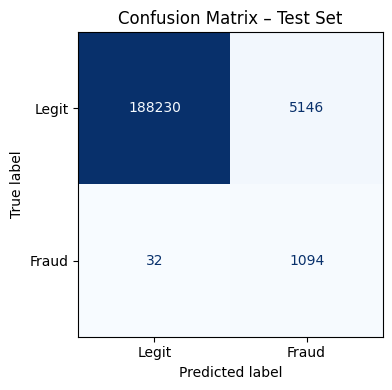

In [25]:
THRESHOLD = 0.5

model.eval()
all_probs  = []
all_labels = []

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        probs = torch.sigmoid(model(Xb)).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(yb.numpy())

all_probs  = np.vstack(all_probs).flatten()
all_labels = np.vstack(all_labels).flatten()
y_pred     = (all_probs >= THRESHOLD).astype(int)

print(f"ROC-AUC : {roc_auc_score(all_labels, all_probs):.4f}")
print()
print(classification_report(all_labels, y_pred, target_names=["Legit","Fraud"]))

cm   = confusion_matrix(all_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit","Fraud"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix – Test Set")
plt.tight_layout()
plt.show()

### Save What the Prediction Notebook Needs

Your prediction notebook should be able to `Run all` without retraining.
So save:
- the trained model weights
- the scaler
- the encoder
- the list of feature columns / metadata needed for preprocessing


In [26]:
torch.save(model.state_dict(), "fraud_mlp_state_dict.pt")
joblib.dump(scaler,       "fraud_scaler.joblib")
joblib.dump(encoder,      "fraud_encoder.joblib")
joblib.dump(feature_cols, "fraud_feature_cols.joblib")
joblib.dump({"input_dim": X_train_s.shape[1]}, "fraud_model_meta.joblib")

print("Saved:")
print("  fraud_mlp_state_dict.pt")
print("  fraud_scaler.joblib")
print("  fraud_encoder.joblib")
print("  fraud_feature_cols.joblib")
print("  fraud_model_meta.joblib")

Saved:
  fraud_mlp_state_dict.pt
  fraud_scaler.joblib
  fraud_encoder.joblib
  fraud_feature_cols.joblib
  fraud_model_meta.joblib


## Short Explanation (write your own)

## Approach Summary

### Imbalanced Data
The dataset contains roughly 0.6% fraudulent transactions — a severe class imbalance.
We addressed this using `WeightedRandomSampler`, which oversamples the minority fraud
class during training so every batch sees a balanced mix. This forces the model to learn
meaningful fraud patterns rather than always predicting legitimate.

### Location Variables
Instead of feeding four raw coordinate columns (lat, long, merch_lat, merch_long)
directly into the network, we computed a single `distance_km` feature using the
Haversine formula. This captures the great-circle distance between the cardholder's
home address and the merchant. Fraudulent transactions tend to occur unusually far
from the cardholder's home, making this a compact and highly informative signal.

### Time Variables
The raw transaction timestamp was decomposed into cyclic features — sin/cos pairs
for hour of day and day of week — so the model correctly understands that 11 PM
is close to midnight rather than treating hour 23 as numerically far from hour 0.
Month was retained as a plain integer. Date of birth was converted to `customer_age`
in decimal years at the time of each transaction, capturing life-stage spending behaviour.

### Model Structure
A three-layer MLP: Linear(128) → BatchNorm → ReLU → Dropout(0.3),
Linear(64) → BatchNorm → ReLU → Dropout(0.3), Linear(32) → ReLU → Dropout(0.2),
ending in a single logit output. `BCEWithLogitsLoss` handles the sigmoid internally
for numerical stability. BatchNorm stabilises training across large batches;
Dropout prevents co-adaptation of neurons.

### Optimisation
Adam (lr=0.001) with `ReduceLROnPlateau` halving the learning rate when validation
AUC plateaus. Best model weights are restored at the end of training based on
peak validation AUC, ensuring we keep the most generalised checkpoint rather
than the final epoch.
